In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import ellipk
from scipy.signal import find_peaks, peak_widths
from scipy.constants import mu_0, epsilon_0
from scipy.optimize import root, curve_fit
from functools import partial
from scipy.io import loadmat

In [6]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [7]:
import h5py

In [2]:
def del_sol(delta, a, phi_ext_val):
    
    lhs = delta + a * np.sin(delta)
    
    return lhs - phi_ext_val


# calculates the impedance of the coupling capacitor to the transmission line (not shown in the setup)
def c_cap(c_c, w):
    return np.array([[1,1/(1j*c_c*w)],[0,1]])

# calculates the impedance of the resonator
def tline(Z0, beta, L):
    return np.array([[np.cos(beta*L),1j*Z0*np.sin(beta*L)],[1j*(1/Z0)*np.sin(beta*L),np.cos(beta*L)]])


def Z_L(L_01, L_02, L_T, d, w, R):
    ZL01 = 1j*w*L_01
    ZL02 = 1j*w*L_02
    ZLT = 1j*w*L_T/np.cos(d)
    ZL02R = (1/ZL02 + 1/R)**(-1)
    ZSQUID = (1/ZL01 + 1/(ZLT + ZL02R))**(-1)
    
    return ZSQUID

def Z_tot(ZL, Z0, beta, l, c_c, w):
    x = beta*l
    Z_c = 1/(1j*w*c_c)
    return (Z0*((ZL + 1j*Z0*np.tan(x))/(Z0 + 1j*ZL*np.tan(x)))) + Z_c

def branch(Z):
    return np.array([[1,0], [1/Z, 1]])
    
#calculates the ABCD matrix
def ABCD(M1, M2, M3):
    full_M = M1 @ M2 @ M3 
    
    return full_M
#Calculates the S21 parameter
def S21(A, B, C, D, Z0):
    return 2/(A + B/Z0 + C*Z0 + D)


def current_to_flux(I, M, o):
    return M*I + o


In [ ]:
def solve_delta(phi_ext, a):
    phi_ext = np.asarray(phi_ext)
    delta = np.zeros_like(phi_ext, dtype=float)
    order = np.argsort(phi_ext)          # continuity in phi_ext, not array position
    d0 = 0.0
    for idx in order:
        sol = root(del_sol, d0, args=(a, phi_ext[idx]))
        delta[idx] = sol.x[0]
        d0 = sol.x[0]
    return delta

def S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, Z0=50):
    """
    X = (I, f): current (A) and frequency (Hz) arrays, same length (elementwise pairs).
    Fit params: L0 (=L01=L02), LT, L_l, C_l, C_c, R_j
    Fixed:      l_f (resonator length), M, O (current -> flux calibration)
    """
    I, f = X
    w = 2 * np.pi * f
    phi_ext = M * I + O #np.pi - 0.5 -0.25 - 0.25 - 0.25

    a = 2 * L0 / LT
    delta = solve_delta(phi_ext, a)

    beta = w * np.sqrt(L_l * C_l)
    ZL = Z_L(L0, L0, LT, delta, w, R_j)
    Ztot = Z_tot(ZL, Z0, beta, l_f, C_c, w)

    return 2 / (2 + Z0 / Ztot)

def S21_fit_mag_dB(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f):
    S21 = S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f)
    return 20 * np.log10(np.abs(S21))

In [8]:
def calc_cpw_param_set(
    center_width: float, gap_width: float, substrate_r: float, metal_thickness: float
):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = (
        a
        + d / 2
        + 3 / 2 * np.log(2) * d
        - d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    u2 = (
        b
        - d / 2
        - 3 / 2 * np.log(2) * d
        + d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d/2
    u1 = a+d/2+3/2*np.log(2)*d-d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    u2 = b-d/2-3/2*np.log(2)*d+d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    k1 = u1/u2
    k2 = np.sqrt(1-k1**2)
    l = mu_0/4*ellipk(k2)/ellipk(k1)

    lambda_eff = 50e-9  # m, effective field penetration depth
    k = a/b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*a/metal_thickness)-k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*b/metal_thickness)-k*np.log((1+k)/(1-k)))
    g = g_ctr+g_gnd
    l_ki = g*mu_0*lambda_eff
    l_tot = l+l_ki

    return {'inductance': l_tot, 'capacitance': c}

def calc_target_length(target_frequency: float, cpw_param_set: dict):
    return 1e6 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



def calc_target_frequency(target_length: float, cpw_param_set: dict):
    return 1e6 / (4 * target_length * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



resonator_widths = [7, 10, 7]
#################################3

res_cpw_param_set = calc_cpw_param_set(
    center_width= resonator_widths[1]*1e-6, 
    gap_width=resonator_widths[0]*1e-6, 
    substrate_r=11.6, 
    metal_thickness=200e-9
)
l = calc_target_length(5.5e9, res_cpw_param_set)
R_L = l/1e6
L_l = res_cpw_param_set['inductance']
C_l = res_cpw_param_set['capacitance']
R_L

np.float64(0.005122618693762872)

In [9]:
mat_data_s21 = loadmat('TC-Main-001-S21-Fit-test1.mat', squeeze_me=True)
mat_data_freq = loadmat('Tc-Main-001-F-fit-test1.mat', squeeze_me=True)
mat_data_current = loadmat('TC-Main-001-I-fit-test1.mat', squeeze_me = True)
mat_data_f0 = loadmat('TC-Main-001-f0-fit-all.mat', squeeze_me = True)
mat_data_I1 = loadmat('TC-Main-001-I1-fit-all.mat', squeeze_me = True)
mat_data_Q_ext = loadmat('TC-Main-001-Q-ext-fit-all.mat', squeeze_me = True)
mat_data_Q_L = loadmat('TC-Main-001-Q-L-fit-all.mat', squeeze_me = True)
mat_data_Q_int = loadmat('TC-Main-001-Q-int-fit-all.mat', squeeze_me = True)

In [10]:
S21_dB = mat_data_s21['S21_fit'] 
Freq = mat_data_freq['F_fit']
I1 = mat_data_current['I_fit']
f0_all = mat_data_f0['f0_all']
I1_all = mat_data_I1['I1_all']
Q_ext_all = mat_data_Q_ext['Qext_all']
Q_L_all = mat_data_Q_L['QL_all']
Q_int_all = mat_data_Q_int['Qi_all']

In [ ]:
from scipy.optimize import curve_fit
def lorentzian_dip_power(f, f0, Q_L, baseline, Q_e_inv):
    """
    Fit model for |S21|^2 in terms of Q factors directly.
    Q_e_inv = 1/Q_e (easier to fit as a free parameter)
    """
    depth_amplitude = Q_L * Q_e_inv          # = Q_L / Q_e
    lorentz = depth_amplitude / (1 + 4 * Q_L**2 * ((f - f0)/f0)**2)
    # |S21|^2 = baseline * |1 - lorentz|^2
    return baseline * (1 - lorentz)**2


def calculate_q_factors(freq, S21_vals):

    # Ensure freq is a flat 1D array
    #freq = np.asarray(freq).flatten()
    n_flux = S21_vals.shape[1]
    
    q_loaded = np.zeros(n_flux)
    q_internal = np.zeros(n_flux)
    q_external = np.zeros(n_flux)
    f0_fits = np.zeros(n_flux)
    
    for i in range(n_flux):
        power = np.abs(S21_vals[:, i])**2
        
        baseline_guess = np.max(power)
        min_idx = np.argmin(power)
        f0_guess = freq[min_idx]
        S21_min = np.sqrt(power[min_idx] / baseline_guess)
        
        # Estimate df (FWHM) by finding points below the half-depth
        half_max = baseline_guess - (baseline_guess - power[min_idx]) / 2.0
        below_half = np.where(power < half_max)[0]
        
        df_guess = freq[below_half[-1]] - freq[below_half[0]]

        Q_L_guess = f0_guess/df_guess
        
        dip = np.clip(1.0-S21_min, 1e-6, 2.0)
        Qe_inv_guess = dip/Q_L_guess
                 
        p0 = [f0_guess, Q_L_guess, baseline_guess, Qe_inv_guess]
        
        popt, _ = curve_fit(lorentzian_dip_power, freq, power,
                            p0=p0, maxfev=10000)
        f0_fit, Q_L_fit, _, Qe_inv_fit = popt
        Q_L_fit = np.abs(Q_L_fit)
        Q_e_fit = 1.0 / np.abs(Qe_inv_fit)
        
        Q_i_fit = 1.0 / (1.0/Q_L_fit - 1.0/Q_e_fit)

        q_loaded[i]   = Q_L_fit
        q_external[i] = Q_e_fit
        q_internal[i] = Q_i_fit
        f0_fits[i]    = f0_fit

    return q_loaded, q_internal, q_external, f0_fits

In [ ]:
#Basic fitting of all the q-factors and f0 values to the data using summary_residual.

def model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, f_bounds, n_freq=400):
    """Generate dense model S21 per current, extract Q_i/Q_ext/f0 via the same
    Lorentzian-fit machinery used on the real data."""
    f_dense = np.linspace(*f_bounds, n_freq)
    S21_grid = np.zeros((n_freq, len(I_arr)), dtype=complex)

    for k, I_val in enumerate(I_arr):
        S21_grid[:, k] = S21_fit_func(
            (np.full(n_freq, I_val), f_dense),
            L0, LT, L_l, C_l, C_c, R_j, M, O, l_f
        )

    q_L, q_i, q_e, f0_arr = calculate_q_factors(f_dense, S21_grid)
    return q_L, q_i, q_e, f0_arr

def summary_residuals(params, I_arr, Qi_data, Qe_data, f0_data, QL_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)  # Lorentzian fit failed -- penalize heavily

    # log-space for Q's (span decades); linear (normalized) for f0
    res_qi = np.log10(q_i) - np.log10(Qi_data)
    res_qe = np.log10(q_e) - np.log10(Qe_data)
    res_qL = np.log10(q_L) - np.log10(QL_data)
    res_f0 = (f0 - f0_data) / 1e6   # scale to MHz so residual magnitude is comparable

    return np.concatenate([res_qi, res_qe, res_qL, res_f0])

In [13]:
from scipy.optimize import least_squares

# updated C_c bounds based on the Q_ext scaling estimate above
O_fixed = np.pi - 1.25
M_mag = 2*np.pi / 2.15e-6  
p0 = [
    0.2e-9,       # L0
    0.45e-9,       # LT
    L_l,          # L_l
    C_l,          # C_l
    51e-15,       # C_c
    20,           # R_j    
    M_mag,        # M     
] 
lower = [0.17e-9, 0.40e-9, 0.6*L_l, 0.6*C_l, 50e-15, 10,  -1.1*M_mag]
upper = [0.22e-9, 0.55e-9, 1.1*L_l, 1.1*C_l, 55e-15, 30, 1.1*M_mag]

res = least_squares(
    summary_residuals, p0,
    args=(I1_all*1e-6, Q_int_all, Q_ext_all, f0_all, Q_L_all,  R_L, (Freq.min(), Freq.max()), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)
L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f = res.x
print(res.x, "cost:", res.cost, 1/(np.sqrt(Ll_f*Cl_f*R_L**2)*4))

[1.80494273e-10 4.34916991e-10 4.84606960e-07 1.29418135e-10
 5.22596818e-14 1.57634180e+01 2.89755848e+06] cost: 10034.198900958267 6162480904.316317


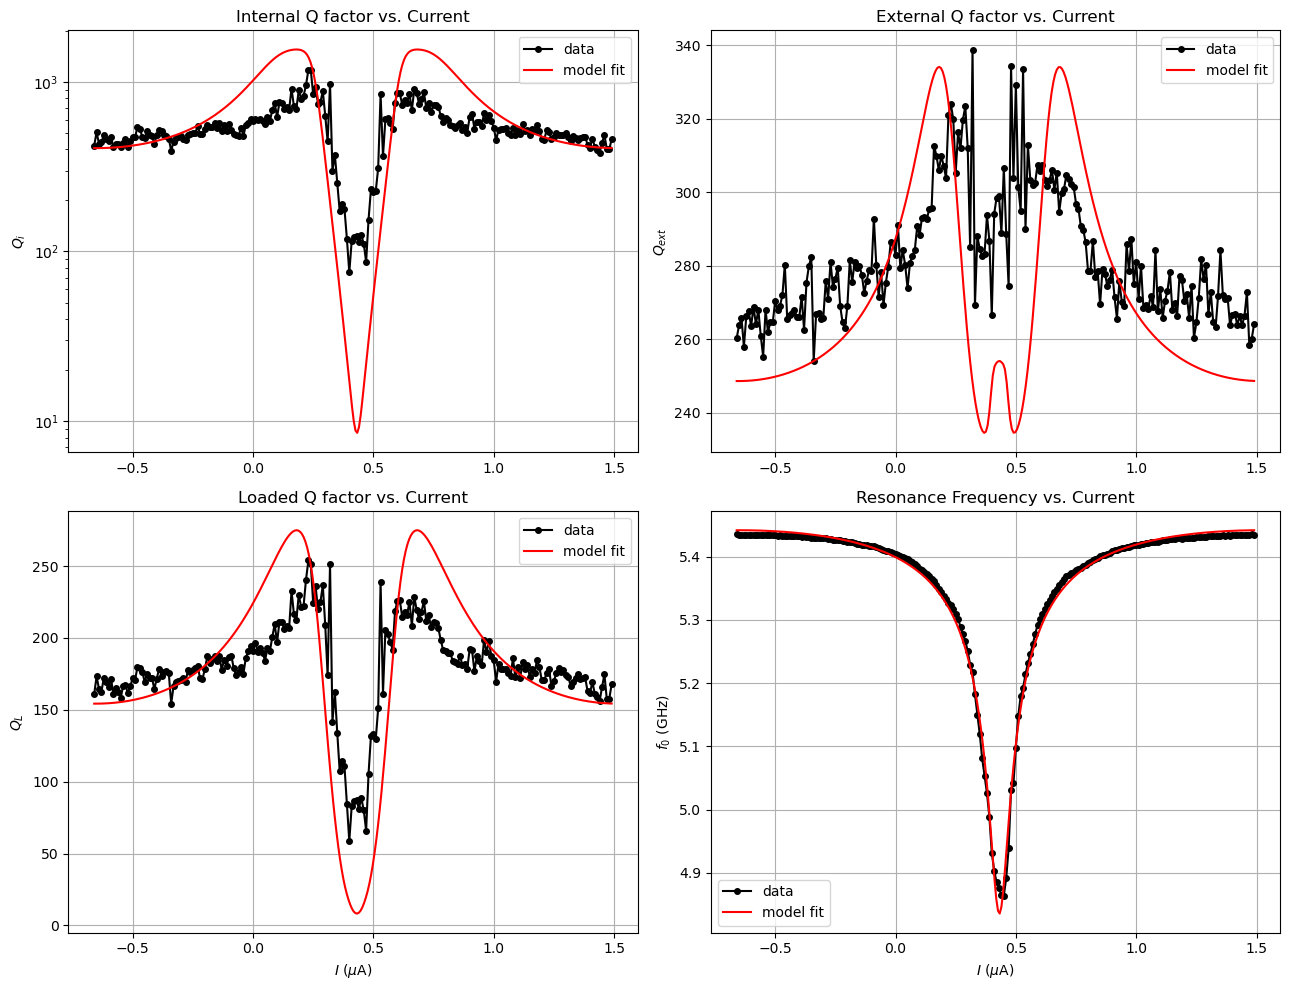

In [15]:
# --- Derive Q_L from Qi/Qext for both data and model (QL = (Qi*Qext)/(Qi+Qext)) ---

# --- Dense current sweep for a smooth model curve ---
I_plot_uA = np.linspace(I1_all.min(), I1_all.max(), 300)
I_plot_A = I_plot_uA * 1e-6

QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, R_L,
    (Freq.min(), Freq.max())
)

# --- 4-panel overlay: data vs. fitted model ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(I1_all, Q_int_all, 'k-o', ms=4, label='data')
axes[0,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='model fit')
axes[0,0].set_ylabel(r'$Q_i$')
axes[0,0].set_yscale('log')
axes[0,0].legend()
axes[0,0].set_title('Internal Q factor vs. Current')
axes[0,0].grid(True)

axes[0,1].plot(I1_all, Q_ext_all, 'k-o', ms=4, label='data')
axes[0,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='model fit')
axes[0,1].set_ylabel(r'$Q_{ext}$')
axes[0,1].legend()
axes[0,1].set_title('External Q factor vs. Current')
axes[0,1].grid(True)

axes[1,0].plot(I1_all, Q_L_all, 'k-o', ms=4, label='data')
axes[1,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='model fit')
axes[1,0].set_ylabel(r'$Q_L$')
axes[1,0].set_xlabel(r'$I$ ($\mu$A)')
axes[1,0].legend()
axes[1,0].set_title('Loaded Q factor vs. Current')
axes[1,0].grid(True)

axes[1,1].plot(I1_all, f0_all/1e9, 'k-o', ms=4, label='data')
axes[1,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='model fit')
axes[1,1].set_ylabel(r'$f_0$ (GHz)')
axes[1,1].set_xlabel(r'$I$ ($\mu$A)')
axes[1,1].legend()
axes[1,1].set_title('Resonance Frequency vs. Current')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
def S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, Q_diel, l_f, Z0=50):
    I, f = X
    w = 2 * np.pi * f
    phi_ext = M * I + O

    a = 2 * L0 / LT
    delta = solve_delta(phi_ext, a)

    C_l_eff = C_l * (1 - 1j / Q_diel)   # flux-independent dielectric loss floor
    beta = w * np.sqrt(L_l * C_l_eff)

    ZL = Z_L(L0, L0, LT, delta, w, R_j)
    Ztot = Z_tot(ZL, Z0, beta, l_f, C_c, w)
    return 2 / (2 + Z0 / Ztot)

def S21_fit_mag_dB(X, L0, LT, L_l, C_l, C_c, R_j, M, O, Q_diel, l_f):
    S21 = S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, Q_diel, l_f)
    return 20 * np.log10(np.abs(S21))

In [13]:
def model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O, Q_diel, l_f, f_bounds, n_freq=400):
    f_dense = np.linspace(*f_bounds, n_freq)
    S21_grid = np.zeros((n_freq, len(I_arr)), dtype=complex)
    for k, I_val in enumerate(I_arr):
        S21_grid[:, k] = S21_fit_func(
            (np.full(n_freq, I_val), f_dense),
            L0, LT, L_l, C_l, C_c, R_j, M, O, Q_diel, l_f
        )
    q_L, q_i, q_e, f0_arr = calculate_q_factors(f_dense, S21_grid)
    return q_L, q_i, q_e, f0_arr

def summary_residuals(params, I_arr, Qi_data, Qe_data, f0_data, QL_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M, Q_diel = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, Q_diel, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)

    res_qi = np.log10(q_i) - np.log10(Qi_data)
    res_qe = np.log10(q_e) - np.log10(Qe_data)
    res_qL = np.log10(q_L) - np.log10(QL_data)
    res_f0 = (f0 - f0_data) / 1e6
    return np.concatenate([res_qi, res_qe, res_qL, res_f0])

In [23]:
# bounds: Q_diel should be well above your max observed Qi (~1000), acting as a ceiling, not the dominant term
p0 = [0.2e-9, 0.45e-9, L_l, C_l, 50e-15, 20, M_mag, 1500]
lower = [0.17e-9, 0.40e-9, 0.6*L_l, 0.6*C_l, 48e-15, 10, -1.1*M_mag, 500]
upper = [0.22e-9, 0.55e-9, 1.1*L_l, 1.1*C_l, 52e-15, 30,  1.1*M_mag, 10000]

res = least_squares(
    summary_residuals, p0,
    args=(I1_all*1e-6, Q_int_all, Q_ext_all, f0_all, Q_L_all, R_L, (Freq.min(), Freq.max()), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)

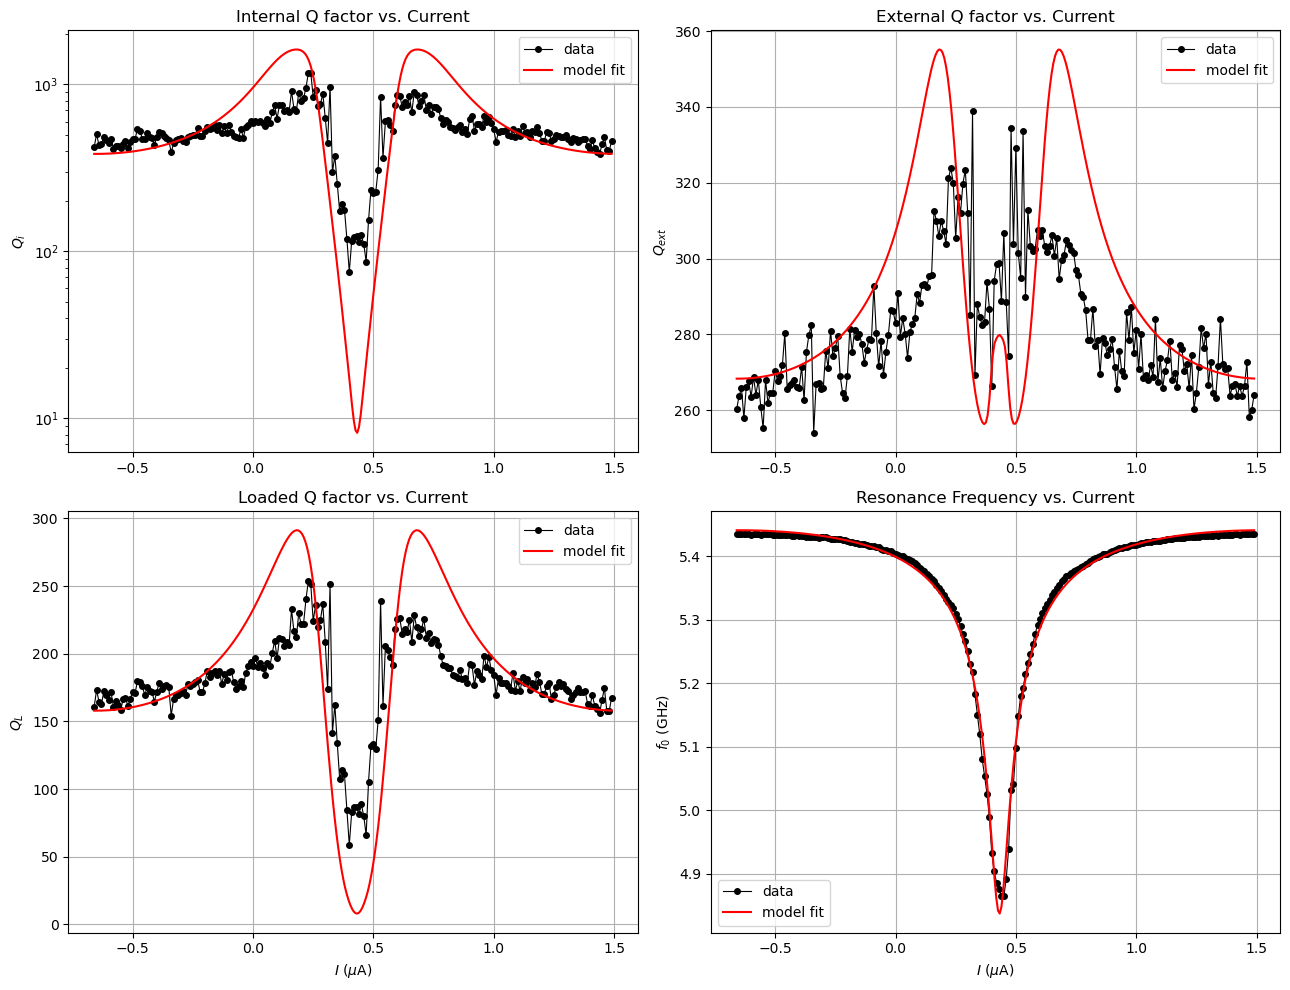

Fitted parameters:
  L0       = 1.78543e-10
  LT       = 4.27151e-10
  L_l      = 4.87025e-07
  C_l      = 1.29805e-10
  C_c      = 4.98472e-14
  R_j      = 15.4192
  M        = 2.89621e+06
  Q_diel   = 5682.15
  a = 2*L0/LT = 0.8360


In [24]:
# --- Unpack fitted parameters ---
L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, Qdiel_f = res.x

# --- Derive Q_L from Qi/Qext for both data and model (QL = (Qi*Qext)/(Qi+Qext)) ---

# --- Dense current sweep for a smooth model curve ---
I_plot_uA = np.linspace(I1_all.min(), I1_all.max(), 300)
I_plot_A = I_plot_uA * 1e-6

QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, Qdiel_f, R_L,
    (Freq.min(), Freq.max())
)


# --- 4-panel overlay: data vs. fitted model ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(I1_all, Q_int_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='model fit')
axes[0,0].set_ylabel(r'$Q_i$')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Internal Q factor vs. Current')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(I1_all, Q_ext_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='model fit')
axes[0,1].set_ylabel(r'$Q_{ext}$')
axes[0,1].set_title('External Q factor vs. Current')
axes[0,1].legend()
axes[0,1].grid(True)

axes[1,0].plot(I1_all, Q_L_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='model fit')
axes[1,0].set_ylabel(r'$Q_L$')
axes[1,0].set_xlabel(r'$I$ ($\mu$A)')
axes[1,0].set_title('Loaded Q factor vs. Current')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(I1_all, f0_all/1e9, 'ko-', ms=4, lw=0.8, label='data')
axes[1,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='model fit')
axes[1,1].set_ylabel(r'$f_0$ (GHz)')
axes[1,1].set_xlabel(r'$I$ ($\mu$A)')
axes[1,1].set_title('Resonance Frequency vs. Current')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print("Fitted parameters:")
for name, val in zip(['L0','LT','L_l','C_l','C_c','R_j','M','Q_diel'], res.x):
    print(f"  {name:8s} = {val:.6g}")
print(f"  a = 2*L0/LT = {2*L0_f/LT_f:.4f}")

In [56]:
def S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, Z0=50):
    """
    X = (I, f): current (A) and frequency (Hz) arrays, same length (elementwise pairs).
    Fit params: L0 (=L01=L02), LT, L_l, C_l, C_c, R_j
    Fixed:      l_f (resonator length), M, O (current -> flux calibration)
    """
    I, f = X
    w = 2 * np.pi * f
    phi_ext = M * I + O #np.pi - 0.5 -0.25 - 0.25 - 0.25

    a = 2 * L0 / LT
    delta = solve_delta(phi_ext, a)

    beta = w * np.sqrt(L_l * C_l)
    ZL = Z_L(L0, L0, LT, delta, w, R_j)
    Ztot = Z_tot(ZL, Z0, beta, l_f, C_c, w)

    return 2 / (2 + Z0 / Ztot)



def model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, f_bounds, n_freq=400):
    """Generate dense model S21 per current, extract Q_i/Q_ext/f0 via the same
    Lorentzian-fit machinery used on the real data."""
    f_dense = np.linspace(*f_bounds, n_freq)
    S21_grid = np.zeros((n_freq, len(I_arr)), dtype=complex)

    for k, I_val in enumerate(I_arr):
        S21_grid[:, k] = S21_fit_func(
            (np.full(n_freq, I_val), f_dense),
            L0, LT, L_l, C_l, C_c, R_j, M, O, l_f
        )

    q_L, q_i, q_e, f0_arr = calculate_q_factors(f_dense, S21_grid)
    return q_L, q_i, q_e, f0_arr

def summary_residuals(params, I_arr, Qi_data, Qe_data, f0_data, QL_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)  # Lorentzian fit failed -- penalize heavily

    # log-space for Q's (span decades); linear (normalized) for f0
    res_qi = np.log10(q_i) - np.log10(Qi_data)
    res_qe = np.log10(q_e) - np.log10(Qe_data)
    res_qL = np.log10(q_L) - np.log10(QL_data)
    res_f0 = (f0 - f0_data) / 1e6   # scale to MHz so residual magnitude is comparable

    return np.concatenate([res_qi, res_qe, res_qL, res_f0])

In [57]:
from scipy.signal import find_peaks

# --- Extract the two target features directly from data ---
QL_min_data = np.min(Q_L_all)

# Find the two flanking peaks in Q_L (I1_all should be sorted ascending already)
peaks, _ = find_peaks(Q_L_all, distance=10)   # tune `distance` if it grabs noise peaks
# keep the two tallest peaks as the "true" flanking maxima
top2 = peaks[np.argsort(Q_L_all[peaks])[-2:]]
top2 = np.sort(top2)
peak_spacing_data = I1_all[top2[1]] - I1_all[top2[0]]   # in µA

print("Data Q_L_min:", QL_min_data, " peak spacing (µA):", peak_spacing_data)

# --- Stage 1: fit ONLY L0, LT to match these two features ---
def stage1_residuals(params, Cc_fixed, Rj_fixed, M_fixed, O_fixed, l_f, f_bounds):
    L0, LT = params
    I_scan = np.linspace(I1_all.min(), I1_all.max(), 300) * 1e-6
    QL_scan, _, _, _ = model_q_factors(I_scan, L0, LT, Ll_f, Cl_f, Cc_fixed, Rj_fixed, M_fixed, O_fixed, l_f, f_bounds)

    QL_min_model = np.min(QL_scan)
    peaks_m, _ = find_peaks(QL_scan, distance=10)
    if len(peaks_m) < 2:
        return np.array([10.0, 10.0])  # penalize: no clear double-peak structure
    top2_m = np.sort(peaks_m[np.argsort(QL_scan[peaks_m])[-2:]])
    spacing_model = (I_scan[top2_m[1]] - I_scan[top2_m[0]]) * 1e6

    return np.array([
        np.log10(QL_min_model) - np.log10(QL_min_data),
        (spacing_model - peak_spacing_data) / 0.1   # normalize; tune scale as needed
    ])

res_stage1 = least_squares(
    stage1_residuals, [0.19e-9, 0.45e-9],
    args=(Cc_f, Rj_f, M_f, O_fixed, R_L, (Freq.min(), Freq.max())),
    bounds=([0.15e-9, 0.45e-9], [0.21e-9, 0.60e-9])
)
L0_stage1, LT_stage1 = res_stage1.x
print("Stage 1 result:", L0_stage1, LT_stage1, " a =", 2*L0_stage1/LT_stage1)

Data Q_L_min: 58.65801755924998  peak spacing (µA): 0.30000000000000016
Stage 1 result: 2.0965294292773054e-10 4.5053613538664384e-10  a = 0.9306820317433997


In [67]:
def stage2_residuals(params, L0_fixed, LT_fixed, M_fixed, O_fixed, l_f, f_bounds):
    R_j, C_c = params
    I_scan = I1_all * 1e-6
    QL_m, Qi_m, Qe_m, f0_m = model_q_factors(I_scan, L0_fixed, LT_fixed, Ll_f, Cl_f, C_c, R_j, M_fixed, O_fixed, l_f, f_bounds)
    return np.concatenate([
        np.log10(Qi_m) - np.log10(Q_int_all),
        np.log10(Qe_m) - np.log10(Q_ext_all),
    ])

res_stage2 = least_squares(
    stage2_residuals, [15, 51e-15],
    args=(L0_stage1, LT_stage1, M_f, O_fixed, R_L, (Freq.min(), Freq.max())),
    bounds=([1, 40e-15], [60, 60e-15])
)
Rj_stage2, Cc_stage2 = res_stage2.x

In [68]:
Rj_stage2, Cc_stage2

(np.float64(27.205413220501143), np.float64(5.537154854071122e-14))

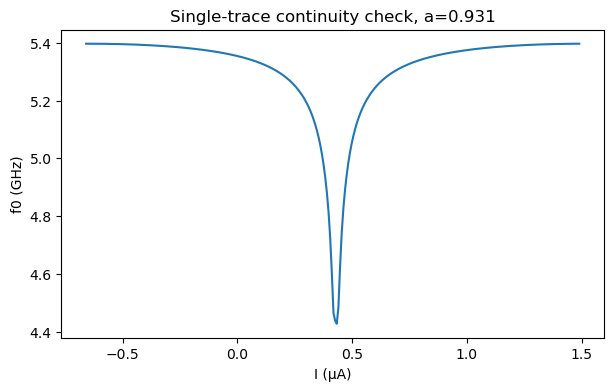

In [63]:
# Quick check: does the fitted resonance stay single-valued across the sweep?
I_check = np.linspace(I1_all.min(), I1_all.max(), 300) * 1e-6
_, _, _, f0_check = model_q_factors(I_check, L0_stage1, LT_stage1, Ll_f, Cl_f, Cc_stage2, Rj_stage2, M_f, O_fixed, R_L, (Freq.min(), Freq.max()))

plt.figure(figsize=(7,4))
plt.plot(I_check*1e6, f0_check/1e9, '-')
plt.xlabel('I (µA)'); plt.ylabel('f0 (GHz)')
plt.title(f'Single-trace continuity check, a={2*L0_stage1/LT_stage1:.3f}')
plt.show()

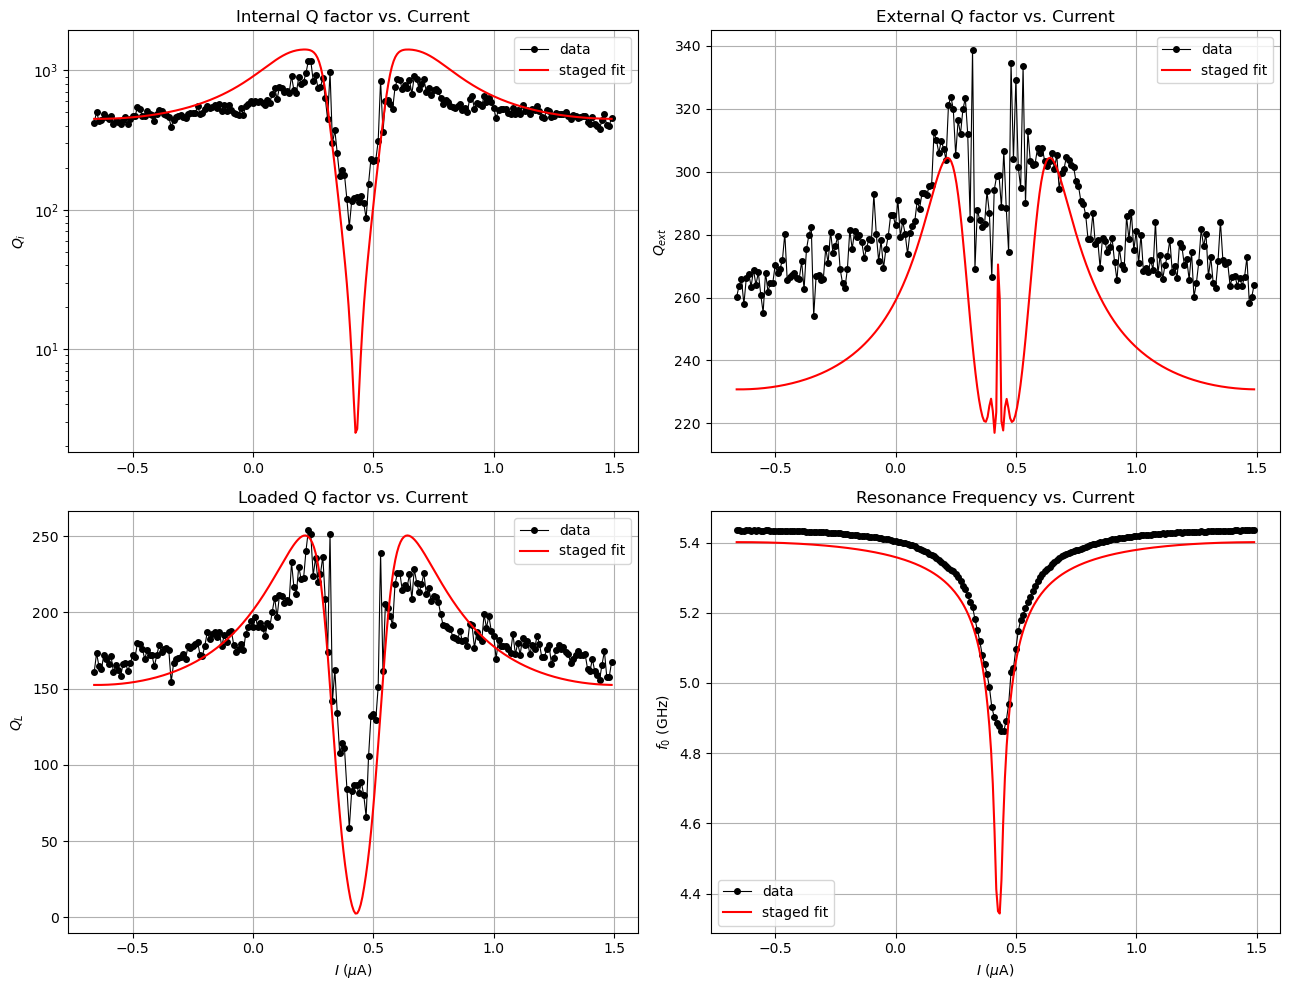

Stage 1 (L0, LT): 2.0965294292773054e-10 4.5053613538664384e-10  a = 0.9306820317433997
Stage 2 (R_j, C_c): 27.205413220501143 5.537154854071122e-14


In [69]:
I_plot_uA = np.linspace(I1_all.min(), I1_all.max(), 300)
I_plot_A = I_plot_uA * 1e-6

QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_stage1, LT_stage1, Ll_f, Cl_f, Cc_stage2, Rj_stage2, M_f, O_fixed, R_L,
    (Freq.min(), Freq.max())
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(I1_all, Q_int_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='staged fit')
axes[0,0].set_ylabel(r'$Q_i$'); axes[0,0].set_yscale('log')
axes[0,0].set_title('Internal Q factor vs. Current'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(I1_all, Q_ext_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='staged fit')
axes[0,1].set_ylabel(r'$Q_{ext}$')
axes[0,1].set_title('External Q factor vs. Current'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(I1_all, Q_L_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='staged fit')
axes[1,0].set_ylabel(r'$Q_L$'); axes[1,0].set_xlabel(r'$I$ ($\mu$A)')
axes[1,0].set_title('Loaded Q factor vs. Current'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(I1_all, f0_all/1e9, 'ko-', ms=4, lw=0.8, label='data')
axes[1,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='staged fit')
axes[1,1].set_ylabel(r'$f_0$ (GHz)'); axes[1,1].set_xlabel(r'$I$ ($\mu$A)')
axes[1,1].set_title('Resonance Frequency vs. Current'); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print("Stage 1 (L0, LT):", L0_stage1, LT_stage1, " a =", 2*L0_stage1/LT_stage1)
print("Stage 2 (R_j, C_c):", Rj_stage2, Cc_stage2)

In [73]:
def pole_weights(I_arr_uA, M, O, sharpness=8):
    """Smoothly down-weight points near phi_ext = pi (mod 2*pi), where the model's
    pole makes exact matching both unreliable in the data and unnecessary to fit."""
    phi_ext = M * (I_arr_uA * 1e-6) + O
    dist = np.abs(np.mod(phi_ext - np.pi + np.pi, 2*np.pi) - np.pi)  # distance to nearest pi (mod 2pi)
    # smooth taper: weight -> 0 right at the pole, -> 1 a bit away from it
    w = 1 - np.exp(-sharpness * dist**2)
    return np.clip(w, 0.05, 1.0)  # keep a small floor so it still contributes a little

def summary_residuals_weighted(params, I_arr, Qi_data, Qe_data, f0_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)

    w = pole_weights(I_arr*1e6, M, O_fixed)

    res_qi = (np.log10(q_i) - np.log10(Qi_data)) * w
    res_qe = (np.log10(q_e) - np.log10(Qe_data)) * w
    res_f0 = ((f0 - f0_data) / 1e6) * w   # f0 also weighted, in case it drifts near the pole too

    return np.concatenate([res_qi, res_qe, res_f0])

In [74]:
p0 = [0.2e-9, 0.45e-9, L_l, C_l, 50e-15, 20, M_mag]  # your best-so-far values as starting point
lower = [0.17e-9, 0.40e-9, 0.6*L_l, 0.6*C_l, 50e-15, 5,  -1.1*M_mag]
upper = [0.22e-9, 0.55e-9, 1.1*L_l, 1.1*C_l, 60e-15, 40, 1.1*M_mag]

res = least_squares(
    summary_residuals_weighted, p0,
    args=(I1_all*1e-6, Q_int_all, Q_ext_all, f0_all, R_L, (Freq.min(), Freq.max()), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)

In [75]:
res.x

array([1.91889144e-10, 4.05864393e-10, 4.85702567e-07, 1.27823306e-10,
       5.45818557e-14, 2.15288425e+01, 2.91511937e+06])

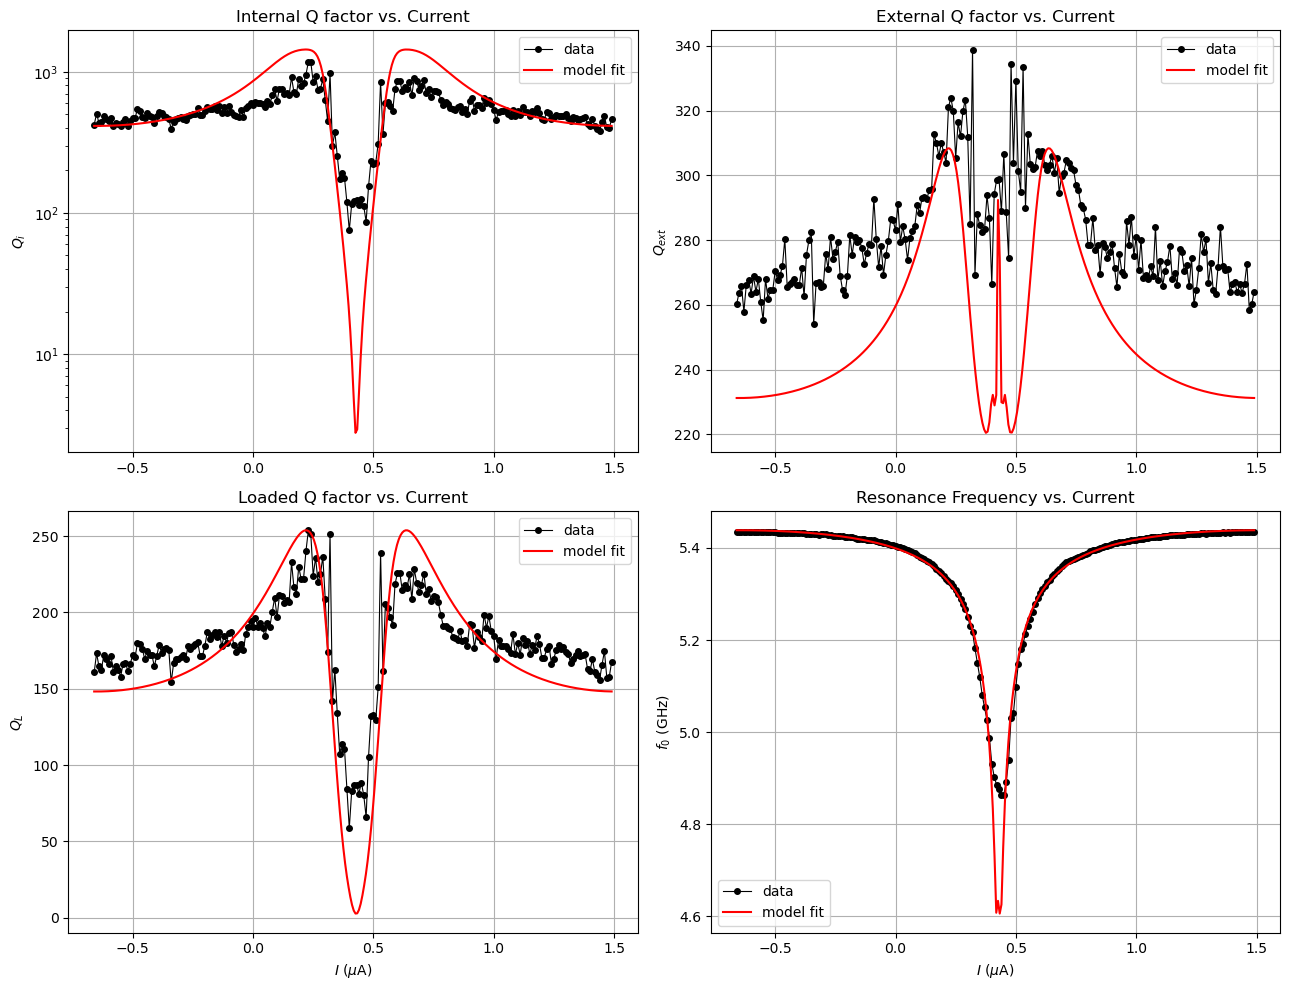

Fitted parameters:
  L0       = 1.91889e-10
  LT       = 4.05864e-10
  L_l      = 4.85703e-07
  C_l      = 1.27823e-10
  C_c      = 5.45819e-14
  R_j      = 21.5288
  M        = 2.91512e+06
  a = 2*L0/LT = 0.9456


In [76]:
L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f = res.x

# --- Derive Q_L from Qi/Qext for both data and model (QL = (Qi*Qext)/(Qi+Qext)) ---

# --- Dense current sweep for a smooth model curve ---
I_plot_uA = np.linspace(I1_all.min(), I1_all.max(), 300)
I_plot_A = I_plot_uA * 1e-6

QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, R_L,
    (Freq.min(), Freq.max())
)


# --- 4-panel overlay: data vs. fitted model ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(I1_all, Q_int_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='model fit')
axes[0,0].set_ylabel(r'$Q_i$')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Internal Q factor vs. Current')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(I1_all, Q_ext_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='model fit')
axes[0,1].set_ylabel(r'$Q_{ext}$')
axes[0,1].set_title('External Q factor vs. Current')
axes[0,1].legend()
axes[0,1].grid(True)

axes[1,0].plot(I1_all, Q_L_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='model fit')
axes[1,0].set_ylabel(r'$Q_L$')
axes[1,0].set_xlabel(r'$I$ ($\mu$A)')
axes[1,0].set_title('Loaded Q factor vs. Current')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(I1_all, f0_all/1e9, 'ko-', ms=4, lw=0.8, label='data')
axes[1,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='model fit')
axes[1,1].set_ylabel(r'$f_0$ (GHz)')
axes[1,1].set_xlabel(r'$I$ ($\mu$A)')
axes[1,1].set_title('Resonance Frequency vs. Current')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print("Fitted parameters:")
for name, val in zip(['L0','LT','L_l','C_l','C_c','R_j','M'], res.x):
    print(f"  {name:8s} = {val:.6g}")
print(f"  a = 2*L0/LT = {2*L0_f/LT_f:.4f}")

In [88]:
def summary_residuals_QL_f0(params, I_arr, QL_data, f0_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(2*len(I_arr), 1e3)

    w = pole_weights(I_arr*1e6, M, O_fixed)

    res_QL = (np.log10(q_L) - np.log10(QL_data)) * w
    res_f0 = ((f0 - f0_data) / 1e6) * w

    return np.concatenate([res_QL, res_f0])

p0 = [0.16e-9, 0.45e-9, L_l, C_l, 50e-15, 20, M_mag]
lower = [0.11e-9, 0.43e-9, 0.6*L_l, 0.6*C_l, 40e-15, 5,  -1.1*M_mag]
upper = [0.22e-9, 0.55e-9, 1.1*L_l, 1.1*C_l, 60e-15, 40, 1.1*M_mag]

res = least_squares(
    summary_residuals_QL_f0, p0,
    args=(I1_all*1e-6, Q_L_all, f0_all, R_L, (Freq.min(), Freq.max()), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)
L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f = res.x
print(res.x, " a =", 2*L0_f/LT_f, " cost:", res.cost)

[1.64314616e-10 4.30068327e-10 4.92327085e-07 1.29679824e-10
 4.92794296e-14 3.98192810e+01 2.92715603e+06]  a = 0.7641326083669356  cost: 2377.686586438195


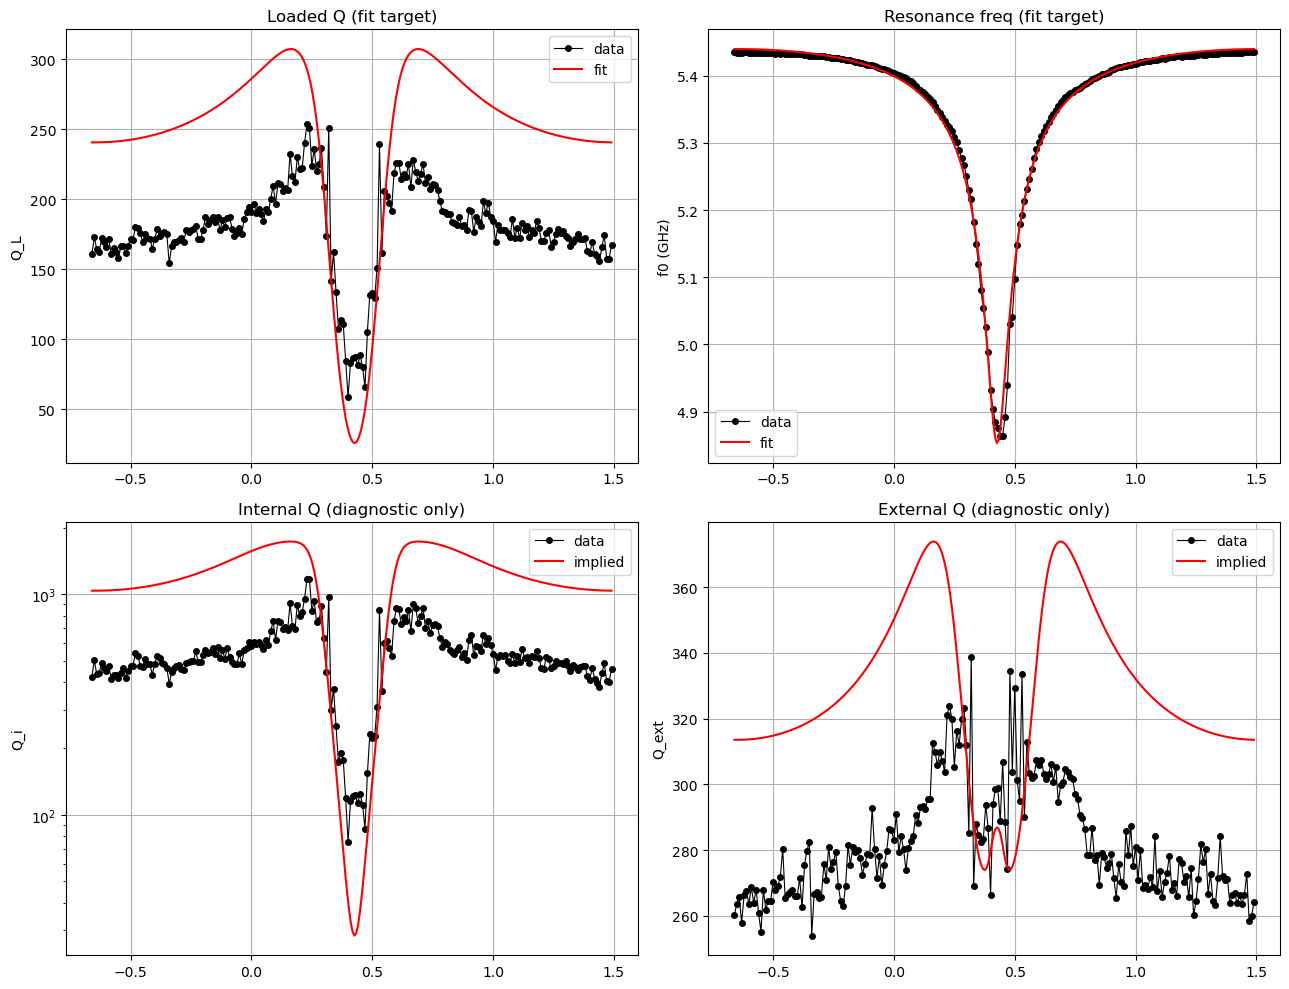

In [89]:
I_plot_uA = np.linspace(I1_all.min(), I1_all.max(), 300)
I_plot_A = I_plot_uA * 1e-6
QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, R_L, (Freq.min(), Freq.max())
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0,0].plot(I1_all, Q_L_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='fit')
axes[0,0].set_ylabel('Q_L'); axes[0,0].set_title('Loaded Q (fit target)'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(I1_all, f0_all/1e9, 'ko-', ms=4, lw=0.8, label='data')
axes[0,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='fit')
axes[0,1].set_ylabel('f0 (GHz)'); axes[0,1].set_title('Resonance freq (fit target)'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(I1_all, Q_int_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='implied')
axes[1,0].set_ylabel('Q_i'); axes[1,0].set_yscale('log'); axes[1,0].set_title('Internal Q (diagnostic only)'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(I1_all, Q_ext_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='implied')
axes[1,1].set_ylabel('Q_ext'); axes[1,1].set_title('External Q (diagnostic only)'); axes[1,1].legend(); axes[1,1].grid(True)
plt.tight_layout(); plt.show()